Data generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-0.1])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
mu_10 = np.array([-0.2, -0.3])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
mu_11 = np.array([0.2, 0.3, -0.1, -0.1])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

In [2]:
policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

In [3]:
def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

In [4]:
num_samples_per_feature = 500

np.random.seed(780)
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)

In [5]:
H = np.inf
theta = 8
lamb = 1
R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

(0, 0) 7.111318148675743
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.211725769323085
Adaptive
Profile (0, 1) took 0.0014922618865966797 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.271654184812738
Adaptive
Profile (1, 0) took 0.007239818572998047 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 7.506292961425322
Adaptive
Profile (1, 1) took 0.016087055206298828 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 4.980434202273533, Max = 12.966336311921037


In [6]:
anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
score_s = AIS.make_score_s_expneg_raw(
    D=D,
    y=y,
    M=M,
    R=R,
    prof_idx_of_policy = prof_idx_of_policy,
    policies=all_policies,
    policy_means=policy_means,
    reg=lamb,
    lattice_edges=None,   # or your edges
    beta=1.0,             # exp(-loss)
    prior_logprob=lambda state: 0.0
)

In [8]:
mcmc_res = MCMC.load_mcmc_res("./toy_50000.pkl.gz")

In [ ]:
log_alpha = [score_s(A) for A in anchors]
mcmc_res = MCMC.run_mcmc(score_s, RPS_states, log_alpha, n_chains=1, steps=200000, burnin=500, thin=5, seed=2, min_len=1)
# MCMC.save_mcmc_res(mcmc_res, "./toy_50000.pkl.gz")

KeyboardInterrupt: 

In [60]:
sample=mcmc_res["samples"]

Text(0.5, 1.0, '50000 MCMC run')

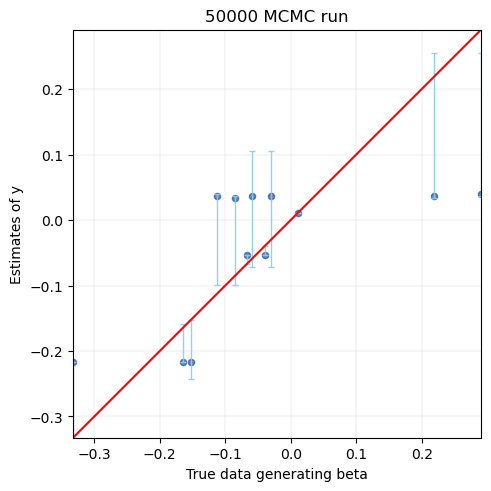

In [9]:
df = MCMC.policy_means_matrix_from_mcmc(
    mcmc_res["samples"],
    all_policies,                     # global list/array of policies (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k
    R_per=R,                        # np.ndarray of arm levels (includes control)
    M=M,
    lattice_edges=None,           # pass None if unused
    policy_labels=None            # optional column names; defaults to policy indices (0..P-1)
)

out = MCMC.summarize_policy_means(df)

MCMC.plot_pred_vs_true(out,                         # output from summarize_policy_means
                      policy_means,
                      point_alpha=0.6,
                      point_color="#0b3d91",     # dark blue
                      bar_color="#87ceeb",       # sky blue
                      line_color="red",
                      figsize=(5,5))

plt.title("50000 MCMC run")

Text(0.5, 1.0, 'RPS of length 20')

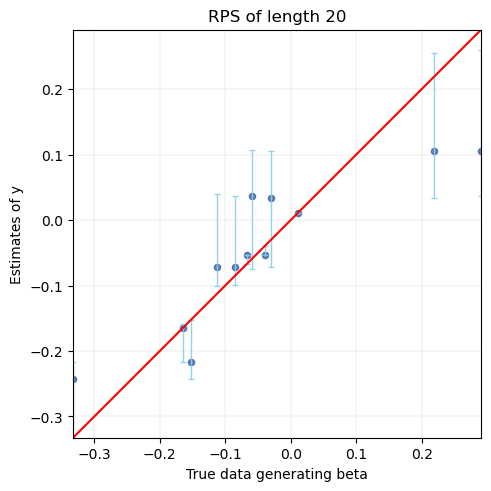

In [10]:
RPS_df = MCMC.policy_means_matrix_from_mcmc(
    RPS_states,
    all_policies,                     # global list/array of policies (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k
    R_per=R,                        # np.ndarray of arm levels (includes control)
    M=M,
    lattice_edges=None,           # pass None if unused
    policy_labels=None            # optional column names; defaults to policy indices (0..P-1)
)

RPS_out = MCMC.summarize_policy_means(RPS_df)

MCMC.plot_pred_vs_true(RPS_out,                         # output from summarize_policy_means
                      policy_means,
                      point_alpha=0.6,
                      point_color="#0b3d91",     # dark blue
                      bar_color="#87ceeb",       # sky blue
                      line_color="red",
                      figsize=(5,5))

plt.title("RPS of length 20")

In [11]:
target_by_profile = {
    0: ((0,0), sigma_00),
    1: ((0,1), sigma_01),
    2: ((1,0), sigma_10),
    3: ((1,1), sigma_11)
}

true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)

In [12]:
RPS_post = []
for partition in RPS_states:
    target_by_profile = {
        0: ((0,0), partition[0].B),
        1: ((0,1), partition[1].B),
        2: ((1,0), partition[2].B),
        3: ((1,1), partition[3].B)
    }
    true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
    RPS_post.append(true_sample["fraction"])

In [14]:
normalized_RPS_post = [i / sum(RPS_post) for i in RPS_post]

In [15]:
RPS_post_exact = []

for partition in RPS_states:
    RPS_post_exact.append(score_s(partition))

normalized_RPS_post_exact = [i / sum(RPS_post_exact) for i in RPS_post_exact]

In [16]:
pd.DataFrame(np.array(normalized_RPS_post),np.array(normalized_RPS_post_exact))

,0
0.173479,0.175766
0.065350,0.061274
0.064414,0.059896
0.063820,0.070285
0.024053,0.020460
0.008849,0.007527
0.008719,0.008269
0.064248,0.063925
0.024202,0.023852
0.023856,0.024382


In [ ]:
# inputs you already have
# profiles: list of profile cov_ids tuples (e.g., [(0,0,0),(0,0,1),...,(1,1,1)])
# R_per: np.array of arm levels (incl. control)
# policies, policy_means, prof_idx_of_policy, D, y: from your pipeline

# Enumerate and score (⚠️ combinatorial; consider a cap for big problems)
from rashomon import AIS
scored = AIS.enumerate_all_states_and_losses(
    profiles=profiles,
    R=R,
    M=M,
    policies=all_policies,
    policy_means=policy_means,
    prof_idx_of_policy=prof_idx_of_policy,
    D=D, y=y,
    reg=lamb, normalize=0,
    lattice_edges=None,
    max_states=None  # or an integer cap to safeguard
)



64

In [28]:
sig = [AIS.state_signature(i[0]) for i in scored]

In [38]:
true_posterior = [np.exp(-i[1]) for i in scored]
norm_true_post = [i/sum(true_posterior) for i in true_posterior]

In [39]:
true_post = []
for partition in RPS_states:
    signature = AIS.state_signature(partition)
    idx = sig.index(signature)
    true_post.append(norm_true_post[idx])

In [41]:
true_post

[np.float64(0.16501531569441152),
 np.float64(0.06216173758662695),
 np.float64(0.06127151236132063),
 np.float64(0.06070613651563208),
 np.float64(0.022879432122264225),
 np.float64(0.008417519733135958),
 np.float64(0.008293326689122037),
 np.float64(0.0611130740689797),
 np.float64(0.02302146838553524),
 np.float64(0.02269177535126581),
 np.float64(0.022482389599470725),
 np.float64(0.008473349422507452),
 np.float64(0.06078707855058023),
 np.float64(0.022898664948873087),
 np.float64(0.022570730596412035),
 np.float64(0.022362461771195132),
 np.float64(0.008428150028111857),
 np.float64(0.02248279702881649),
 np.float64(0.008469333426642755),
 np.float64(0.00834804315145667),
 np.float64(0.008271012541721324),
 np.float64(0.06071734517396665),
 np.float64(0.022872396188062315),
 np.float64(0.0225448380334751),
 np.float64(0.022336808128909914),
 np.float64(0.008418481470680247),
 np.float64(0.022486540702440362),
 np.float64(0.008470743679118022),
 np.float64(0.008349433207547868),

In [44]:
pd.DataFrame({'RPS_estimates':normalized_RPS_post_exact, 'MCMC estimates': normalized_RPS_post, 'ture posterior': true_post})

,RPS_estimates,MCMC estimates,ture posterior
0,0.173479,0.175766,0.165015
1,0.065350,0.061274,0.062162
2,0.064414,0.059896,0.061272
3,0.063820,0.070285,0.060706
4,0.024053,0.020460,0.022879
5,0.008849,0.007527,0.008418
6,0.008719,0.008269,0.008293
7,0.064248,0.063925,0.061113
8,0.024202,0.023852,0.023021
9,0.023856,0.024382,0.022692
